In [1]:
from auxilary.bad_sorts import *
import matplotlib.pyplot as plt
import timeit
import gc

**Experiment 1:**

In [2]:


lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

bubble_times = []
insertion_times = []
selection_times = []

for n in lengths:
    bubble_run_times = []
    insertion_run_times = []
    selection_run_times = []

    for _ in range(runs_per_length):
        L1 = create_random_list(n, max_value)
        L2 = L1.copy()
        L3 = L1.copy()

        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_run_times.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_run_times.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        selection_sort(L3)
        selection_run_times.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_run_times))
    insertion_times.append(min(insertion_run_times))
    selection_times.append(min(selection_run_times))

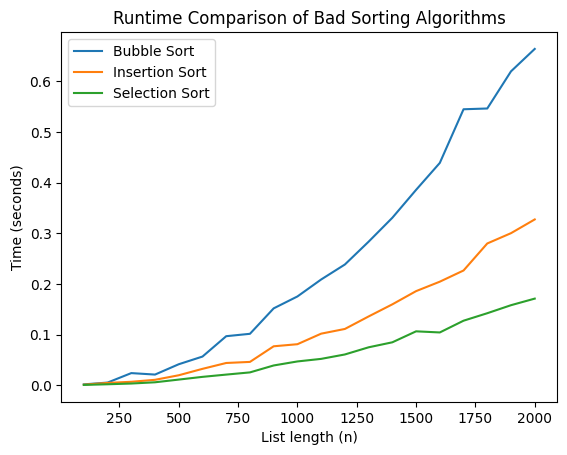

In [3]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, insertion_times, label="Insertion Sort")
plt.plot(lengths, selection_times, label="Selection Sort")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison of Bad Sorting Algorithms")
plt.legend()
plt.show()

Input sizes: 100, 200, 300, …, up to 2000 (increments of 100)

Number of runs per list size: 3 independent runs

Random lists: For each run, a new list of integers between 0 and 10,000 was generated using create_random_list

Algorithms tested: Bubble sort, insertion sort, and selection sort

Timing method: For each run, the time taken by each algorithm to sort the list was recorded using timeit.default_timer()

Data processing: For each list size, the minimum runtime across the 3 runs was used to actually plot the graphs

Plotting: These minimum runtimes were plotted against the corresponding list lengths 

In [4]:
lengths = list(range(10, 501, 10))
runs_per_length = 20
max_value = 10000

bubble_times = []
insertion_times = []
selection_times = []

for n in lengths:
    bubble_run_times = []
    insertion_run_times = []
    selection_run_times = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_run_times.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_run_times.append(timeit.default_timer() - start)

        L3 = L.copy()
        start = timeit.default_timer()
        selection_sort(L3)
        selection_run_times.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_run_times))
    insertion_times.append(min(insertion_run_times))
    selection_times.append(min(selection_run_times))

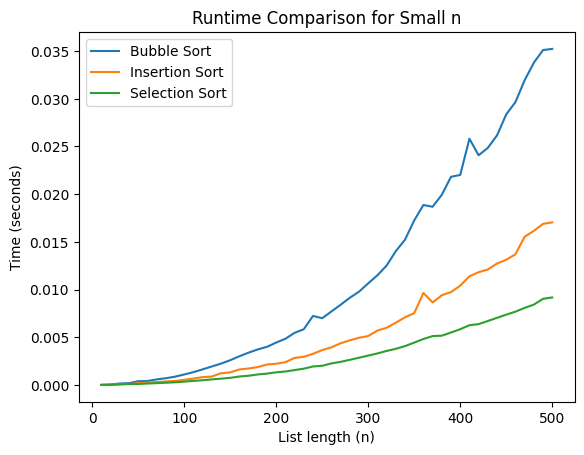

In [5]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, insertion_times, label="Insertion Sort")
plt.plot(lengths, selection_times, label="Selection Sort")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison for Small n")
plt.legend()
plt.show()

Input sizes (list lengths): 10, 20, 30, ... 500 (increments of 10)

Number of runs per list size: 20 independent runs 

Random lists: For each run, a new list of integers between 0 and 10,000 was generated using create_random_list

Algorithms tested: Bubble sort, insertion sort, and selection sort

Timing method: For each run, the time taken by each algorithm to sort the list was recorded using timeit.default_timer()

Data processing: For each list size, the minimum runtime across the 20 runs was used to actually plot the graphs

Plotting: These minimum runtimes were plotted against the corresponding list lengths 

Insertion sort consistently outperformed selection and bubble sort across small and large input sizes. All three algorithms displayed quadratic growth in runtime, as expected from their Θ(n²) time complexity. Bubble sort was the slowest due to unnecessary comparisons and swaps, while insertion sort terminates early which significantly speeds up the execution time.

**Experiment 2:**

In [6]:
def bubble_sort2(L):
    n = len(L)
    for i in range(n):
        j = 0
        while j < n - 1 - i:
            if L[j] > L[j + 1]:
                value = L[j]
                k = j + 1

                while k < n - i and L[k] < value:
                    L[k - 1] = L[k]
                    k += 1

                L[k - 1] = value
                j = k
            else:
                j += 1

In [7]:
def selection_sort2(L):
    left = 0
    right = len(L) - 1

    while left < right:
        min_index = left
        max_index = left

        for i in range(left, right + 1):
            if L[i] < L[min_index]:
                min_index = i
            if L[i] > L[max_index]:
                max_index = i

       
        swap(L, left, min_index)

        
        if max_index == left:
            max_index = min_index

       
        swap(L, right, max_index)

        left += 1
        right -= 1

In [8]:
bubble_times = []
bubble2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    b1_runs = []
    b2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()               
        bubble_sort(L1)
        b1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        bubble_sort2(L2)
        b2_runs.append(timeit.default_timer() - start)

    bubble_times.append(min(b1_runs))
    bubble2_times.append(min(b2_runs))


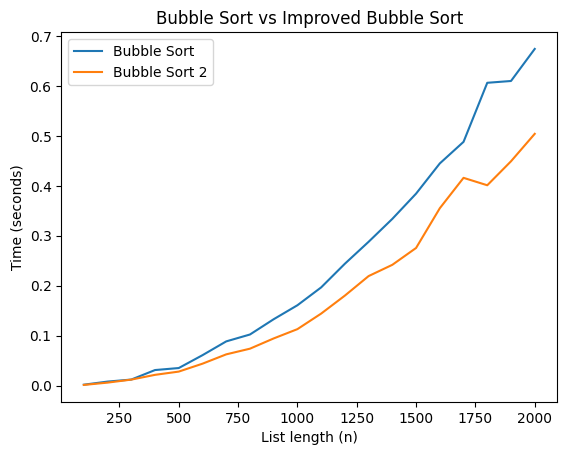

In [ ]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, bubble2_times, label="Bubble Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Bubble Sort vs Improved Bubble Sort")
plt.legend()
plt.show()

In [ ]:
selection_times = []
selection2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    s1_runs = []
    s2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()
        selection_sort(L1)
        s1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        selection_sort2(L2)
        s2_runs.append(timeit.default_timer() - start)

    selection_times.append(min(s1_runs))
    selection2_times.append(min(s2_runs))

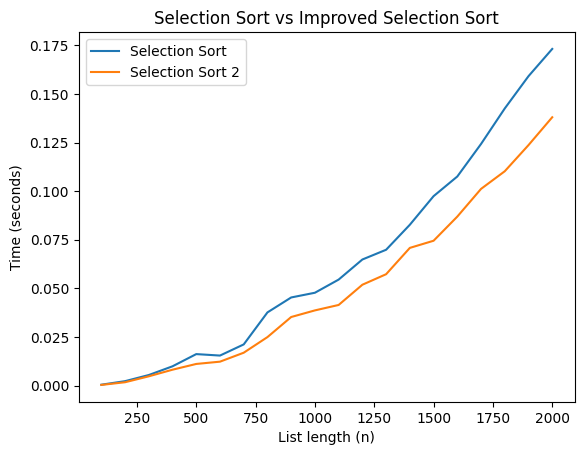

In [ ]:
plt.plot(lengths, selection_times, label="Selection Sort")
plt.plot(lengths, selection2_times, label="Selection Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")                                
plt.title("Selection Sort vs Improved Selection Sort")      
plt.legend()
plt.show()

Experiments were conducted on randomly generated lists of varying sizes. List lengths ranged from 100 to 2000 in increments of 100. Due to the quadratic time complexity for these "bad sorts", I believe an input size of 2000 is sufficient for both analytical purposes and keeping execution time reasonable. For each list length (100, 200, 300...), each algorithm was run 3 times on uniquely generated random lists containing integers between 0 and 10,000. The minimum runtime across the 3 runs was recorded for each algorithm and this data was used to plot the graph.




**Experiment 3**

In [19]:
list_length = 2000
max_value = 10000
runs_per_swap = 5

swaps_list = [0, 10, 50, 100, 250, 500, 1000, 1500, 2000]

bubble_times = []
insertion_times = []
selection_times = []

for swaps in swaps_list:
    bubble_runs = []
    insertion_runs = []
    selection_runs = []

    for _ in range(runs_per_swap):
        L = create_near_sorted_list(list_length, max_value, swaps)

        L1 = L.copy()
        L2 = L.copy()
        L3 = L.copy()

        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_runs.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_runs.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        selection_sort(L3)
        selection_runs.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_runs))
    insertion_times.append(min(insertion_runs))
    selection_times.append(min(selection_runs))

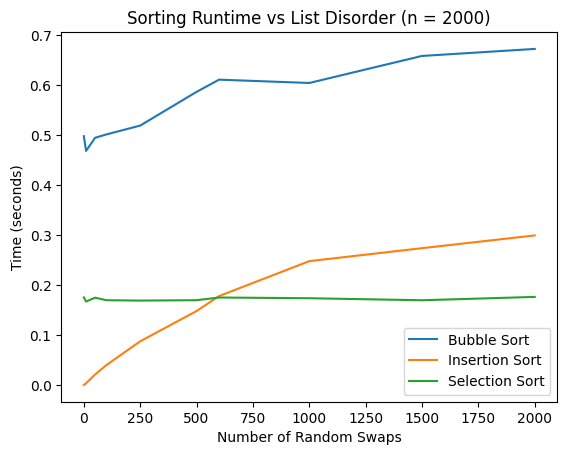

In [16]:
plt.figure()
plt.plot(swaps_list, bubble_times, label="Bubble Sort")
plt.plot(swaps_list, insertion_times, label="Insertion Sort")
plt.plot(swaps_list, selection_times, label="Selection Sort")

plt.xlabel("Number of Random Swaps")
plt.ylabel("Time (seconds)")
plt.title("Sorting Runtime vs List Disorder (n = 2000)")
plt.legend()
plt.show()

**Explicit Outline**

These experiments were performed on the original "bad" sorting algorithms (not their improved counterparts). 

I fixed the list length at n = 2000 and the maximum value at 10000.
I generated near sorted lists using the function provided (create_near_sorted_list)
The number of random swaps was varied from 0 up to 2000 in the intervals (0, 10, 50, 100, 250, 500, 1000, 1500, 2000)
For each swap count, I ran 5 trials and recorded the minimum execution time for more consistent results.

**Conclusion**

The experiment shows interesting aspects of each sorting algorithm.

Insertion Sort seems very sensitive to the amount of disorder in the list. When the number of swaps is small (Seeming to be around 600), Insertion Sort is the best performing algorithm of the three, as it requires minimal shifting. However, as the number of swaps increases, its runtime grows rapidly and it performs worse than selection sort, but not as bad as bubble sort.

Bubble Sort also benefits from near-sorted input, but to a lesser extent, as it still requires repeated passes through the list. Overall it is the worst-performing algorithm in all cases.

Selection Sort has very stable performance regardless of disorder since it always performs the same number of comparisons and swaps, even when the list is nearly sorted.

Overall, I think this experiment highlights how algorithms like Insertion Sort can significantly outperform others when the input is nearly sorted, despite having the same worst-case time complexity.